# Task 4 — Email Spam Detection with Machine Learning

## Objective

The objective of this project is to build a Natural Language Processing (NLP) binary classification model capable of distinguishing spam messages from legitimate (ham) messages.

The project covers:
- Exploratory Data Analysis
- Text preprocessing
- TF-IDF feature extraction
- Machine Learning classification
- Model evaluation
- Comparison between different classifiers

In [3]:
#Import Libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [13]:
#Load Dataset:
df = pd.read_csv("../data/spam.csv", encoding="latin-1")

In [14]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [15]:
#Understand Dataset
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (5572, 5)

Columns:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [17]:
df.describe(include="all")

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [18]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [19]:
df = df[["v1", "v2"]]

In [20]:
df.columns = ["label", "message"]

In [21]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [22]:
print("Number of duplicates:", df.duplicated().sum())

Number of duplicates: 403


In [23]:
df = df.drop_duplicates()

In [24]:
print(df.isnull().sum())

label      0
message    0
dtype: int64


## Dataset Description

The dataset contains text messages labeled as either:

- **ham** — legitimate messages
- **spam** — unwanted messages

Each observation represents one message that will be used to train a binary classification model.

In [25]:
class_counts = df["label"].value_counts()

print(class_counts)

label
ham     4516
spam     653
Name: count, dtype: int64


In [26]:
class_percentages = df["label"].value_counts(normalize=True) * 100

print(class_percentages)

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64


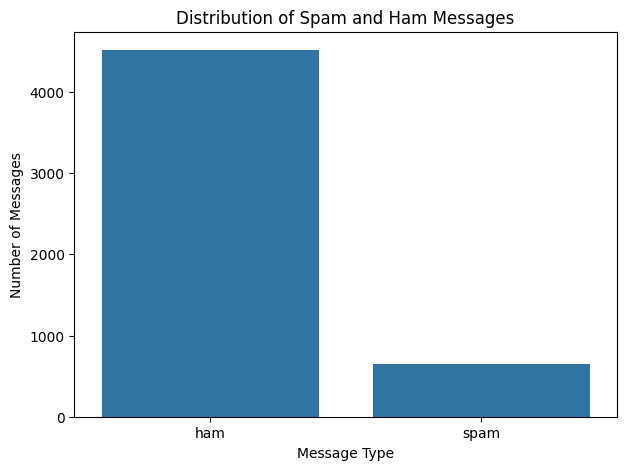

In [27]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="label")

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

## Class Distribution Analysis

The dataset contains significantly more legitimate (ham) messages than spam messages.

This indicates that the dataset is imbalanced. Therefore, accuracy alone should not be used to evaluate the models because a model could achieve high accuracy simply by predicting the majority class most of the time.

For this reason, precision, recall, F1-score, and the confusion matrix will also be considered.